Starting CatBoost Time-Series Cross-Validation...
Fold 1: R²=0.9155, MSE=0.0055, MAE=0.0391
Fold 2: R²=0.4547, MSE=0.0277, MAE=0.0572
Fold 3: R²=0.9096, MSE=0.0047, MAE=0.0398
Fold 4: R²=0.9480, MSE=0.0035, MAE=0.0353
Fold 5: R²=0.9588, MSE=0.0021, MAE=0.0288

========= CATBOOST TIME-SERIES CV RESULTS =========
MAE  : 0.040 ± 0.009
MSE  : 0.0087 ± 0.0096
R²   : 0.8373 ± 0.1922
MAPE : 32.12% ± 29.51%

DIEBOLD-MARIANO TEST: p-value = 0.0000


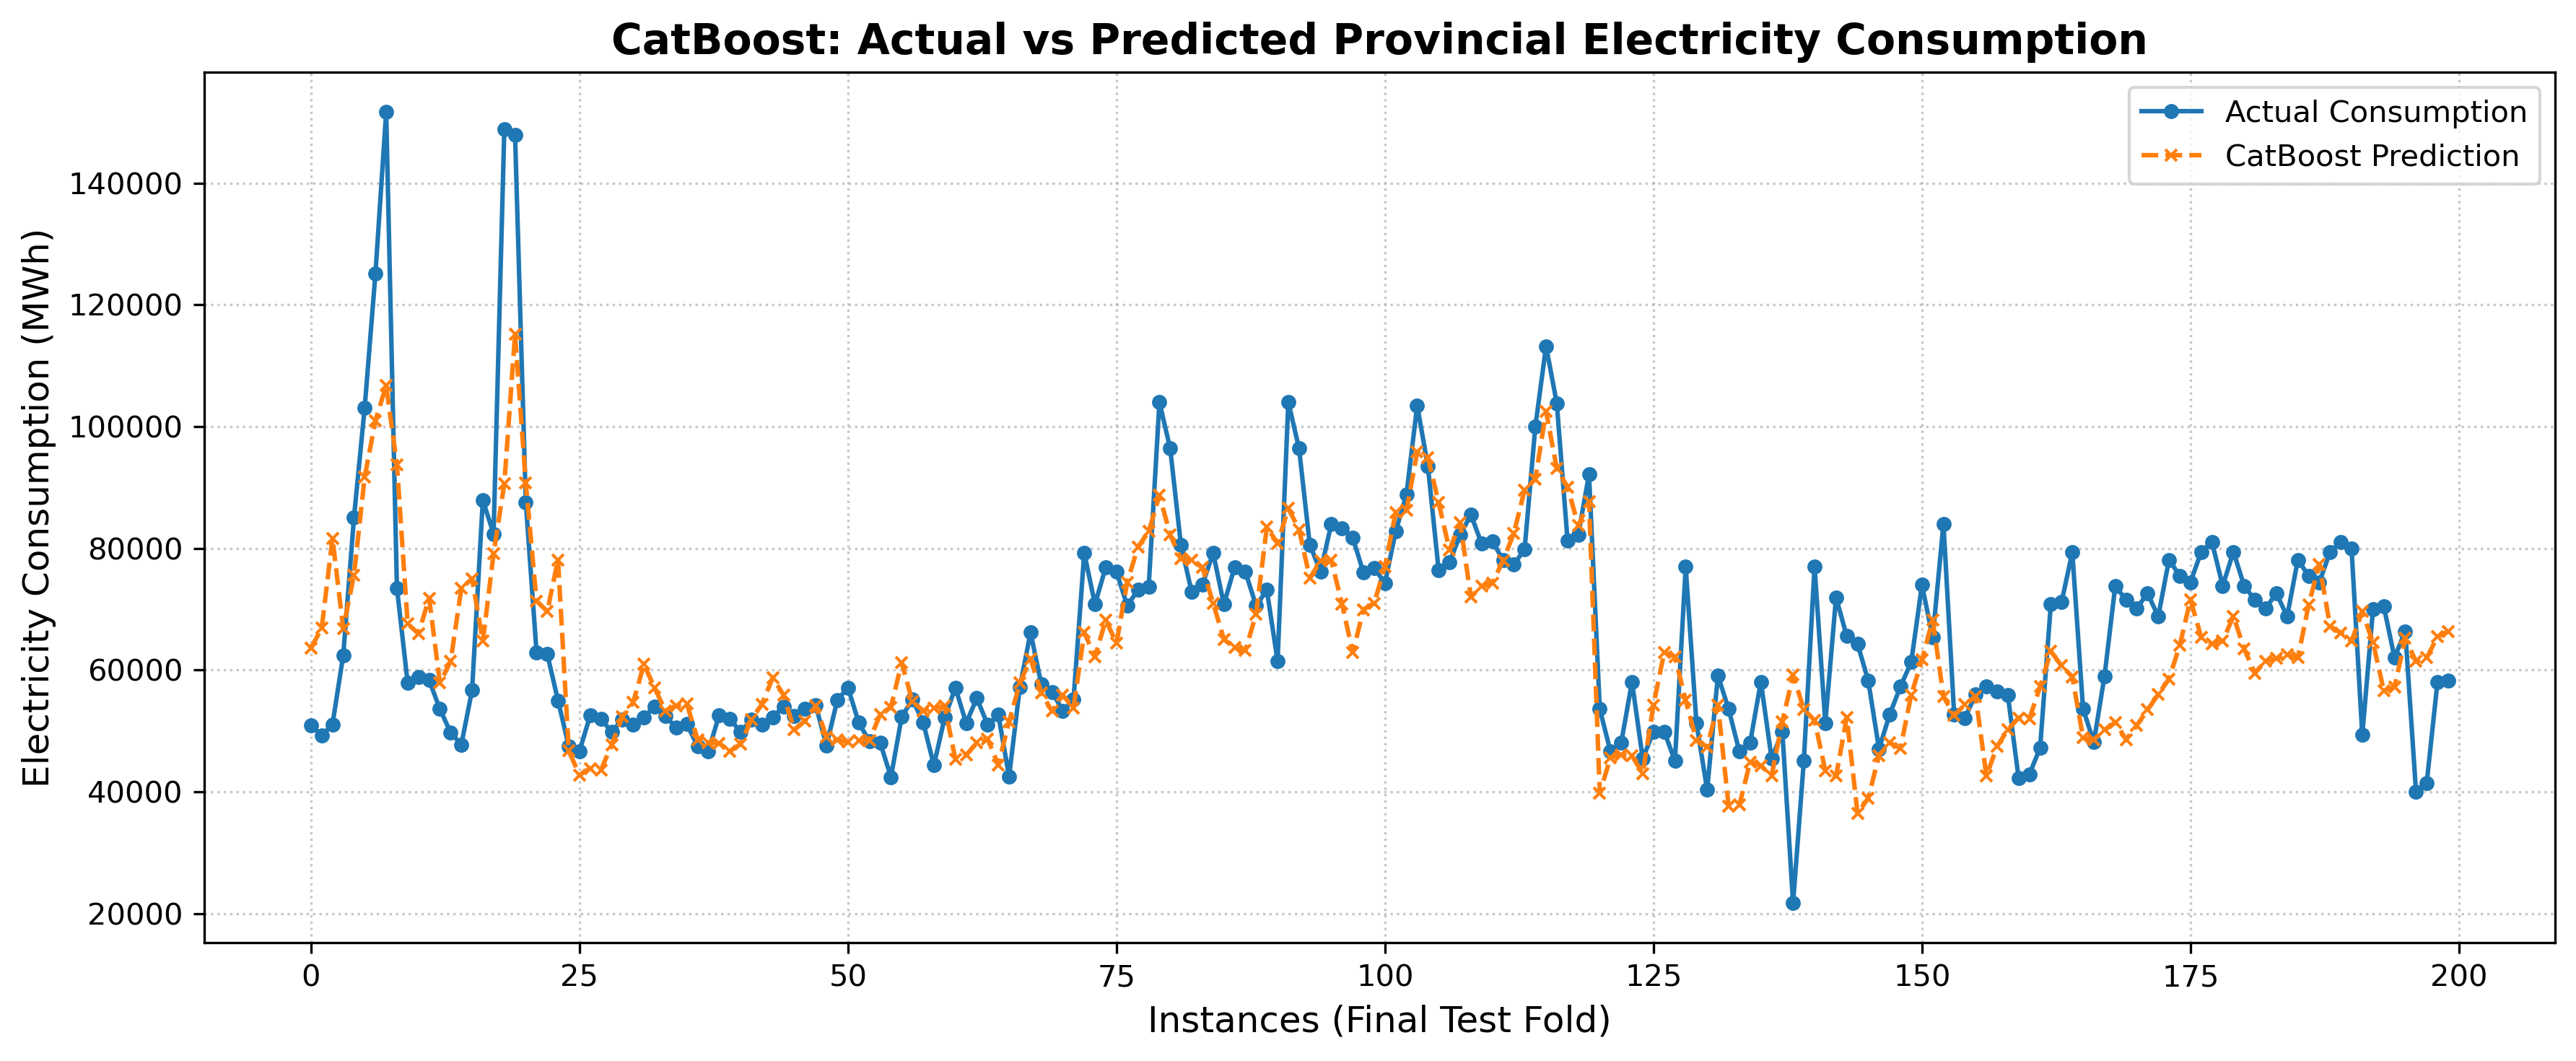

In [7]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ---------------------------------------------------------
# 1) DIEBOLD-MARIANO TEST FUNCTION
# ---------------------------------------------------------
def diebold_mariano(y_true, y_pred1, y_pred2):
    e1 = y_true - y_pred1
    e2 = y_true - y_pred2
    d = e1**2 - e2**2
    mean_d = np.mean(d)
    var_d = np.var(d, ddof=1)
    dm_stat = mean_d / np.sqrt(var_d / len(d))
    p_value = 2 * (1 - stats.norm.cdf(np.abs(dm_stat)))
    return dm_stat, p_value

def main():
    # ---------------------------------------------------------
    # 2) DATA LOADING
    # ---------------------------------------------------------
    OUTPUT_PATH = os.path.join("..", "..", "processed_data", "final", "ML_En.xlsx")
    
    df = pd.read_excel(OUTPUT_PATH)
    df["Plate"] = df["Plate"].astype(str).str.lower()
    df = df.sort_values(["Plate", "Year", "Month"]).reset_index(drop=True)

    # ---------------------------------------------------------
    # 3) LAG FEATURES
    # ---------------------------------------------------------
    lag = 12
    for l in range(1, lag + 1):
        df[f"lag_{l}"] = df.groupby("Plate")["Consumption"].shift(l)

    df = df.dropna().reset_index(drop=True)

    # ---------------------------------------------------------
    # 4) FEATURE ENGINEERING
    # ---------------------------------------------------------
    features = [
        "Lighting", "Public", "Residential", "Industry", "Agriculture",
        "Population", "Month", "Season", "Region", "Latitude", "Longitude",
        "Daylight Duration", "Altitude"
    ] + [f"lag_{i}" for i in range(1, lag + 1)]

    X = df[features].copy()
    y = df["Consumption"].values

    cat_cols = ["Region", "Season"]
    for col in cat_cols:
        X[col] = X[col].astype(str)

    cat_features_indices = [X.columns.get_loc(c) for c in cat_cols]

    # ---------------------------------------------------------
    # 5) TIME SERIES CROSS-VALIDATION
    # ---------------------------------------------------------
    tscv = TimeSeriesSplit(n_splits=5)
    fold_metrics = []

    print("Starting CatBoost Time-Series Cross-Validation...")

    final_y_true = None
    final_y_pred = None

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X), 1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        train_pool = Pool(X_train, y_train, cat_features=cat_features_indices)
        test_pool  = Pool(X_test, y_test, cat_features=cat_features_indices)

        model = CatBoostRegressor(
            iterations=800,
            learning_rate=0.05,
            depth=6,
            eval_metric='RMSE',
            random_seed=42,
            verbose=0
        )

        model.fit(train_pool, eval_set=test_pool, early_stopping_rounds=50, verbose=0)
        y_pred = model.predict(X_test)

        # --- KRİTİK METRİK DÖNÜŞÜMÜ (0.xxx formatı için) ---
        y_max_fold = y_test.max() if y_test.max() != 0 else 1
        y_test_norm = y_test / y_max_fold
        y_pred_norm = y_pred / y_max_fold

        mse_norm = mean_squared_error(y_test_norm, y_pred_norm)
        mae_norm = mean_absolute_error(y_test_norm, y_pred_norm)
        r2 = r2_score(y_test, y_pred)
        mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

        fold_metrics.append([r2, mse_norm, mae_norm, mape])
        print(f"Fold {fold}: R²={r2:.4f}, MSE={mse_norm:.4f}, MAE={mae_norm:.4f}")

        if fold == tscv.n_splits:
            final_y_true = y_test # Grafikte orijinal birim kalsın diye ham değer
            final_y_pred = y_pred

    # ---------------------------------------------------------
    # 6) AVERAGE CV RESULTS (Mean ± STD)
    # ---------------------------------------------------------
    fold_metrics = np.array(fold_metrics)
    print("\n" + "="*45)
    print("========= CATBOOST TIME-SERIES CV RESULTS =========")
    print("="*45)
    print(f"MAE  : {fold_metrics[:,2].mean():.3f} ± {fold_metrics[:,2].std():.3f}")
    print(f"MSE  : {fold_metrics[:,1].mean():.4f} ± {fold_metrics[:,1].std():.4f}")
    print(f"R²   : {fold_metrics[:,0].mean():.4f} ± {fold_metrics[:,0].std():.4f}")
    print(f"MAPE : {fold_metrics[:,3].mean():.2f}% ± {fold_metrics[:,3].std():.2f}%")
    print("="*45)

    # ---------------------------------------------------------
    # 7) DIEBOLD-MARIANO TEST
    # ---------------------------------------------------------
    y_naive = pd.Series(final_y_true).shift(12).bfill().values
    dm_stat, p_value = diebold_mariano(final_y_true, final_y_pred, y_naive)
    print(f"\nDIEBOLD-MARIANO TEST: p-value = {p_value:.4f}")

    # ---------------------------------------------------------
    # 8) PLOTTING (GRAFİK ORİJİNAL MWh DEĞERLERİYLE)
    # ---------------------------------------------------------
    plt.figure(figsize=(12, 5), dpi=300) 
    plot_limit = min(200, len(final_y_true))
    
    plt.plot(final_y_true[:plot_limit], label='Actual Consumption', color='#1f77b4', marker='o', markersize=4, linewidth=1.5)
    plt.plot(final_y_pred[:plot_limit], label='CatBoost Prediction', color='#ff7f0e', marker='x', markersize=4, linestyle='--', linewidth=1.5)
    
    plt.title("CatBoost: Actual vs Predicted Provincial Electricity Consumption", fontsize=14, fontweight='bold')
    plt.xlabel("Instances (Final Test Fold)", fontsize=12)
    plt.ylabel("Electricity Consumption (MWh)", fontsize=12)
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.tight_layout()
    plt.savefig("catboost_final_plot.png")
    plt.show()

if __name__ == "__main__":
    main()

Starting CatBoost Time-Series Cross-Validation...
Fold 1 completed: R²=0.9155, NMSE=0.0058, NMAE=0.0399
Fold 2 completed: R²=0.4547, NMSE=0.0280, NMAE=0.0575
Fold 3 completed: R²=0.9096, NMSE=0.0053, NMAE=0.0420
Fold 4 completed: R²=0.9480, NMSE=0.0036, NMAE=0.0355
Fold 5 completed: R²=0.9588, NMSE=0.0022, NMAE=0.0295

========= CATBOOST TIME-SERIES CV RESULTS =========
NMAE : 0.0409 ± 0.0094
NMSE : 0.0090 ± 0.0096
R²   : 0.8373 ± 0.1922
MAPE : 32.12% ± 29.51%

========== DIEBOLD-MARIANO TEST RESULT ==========
Comparison : CatBoost Prediction vs. Naive Baseline (Lag 12)
DM Stat    : -5.3783
p-value    : 0.0000


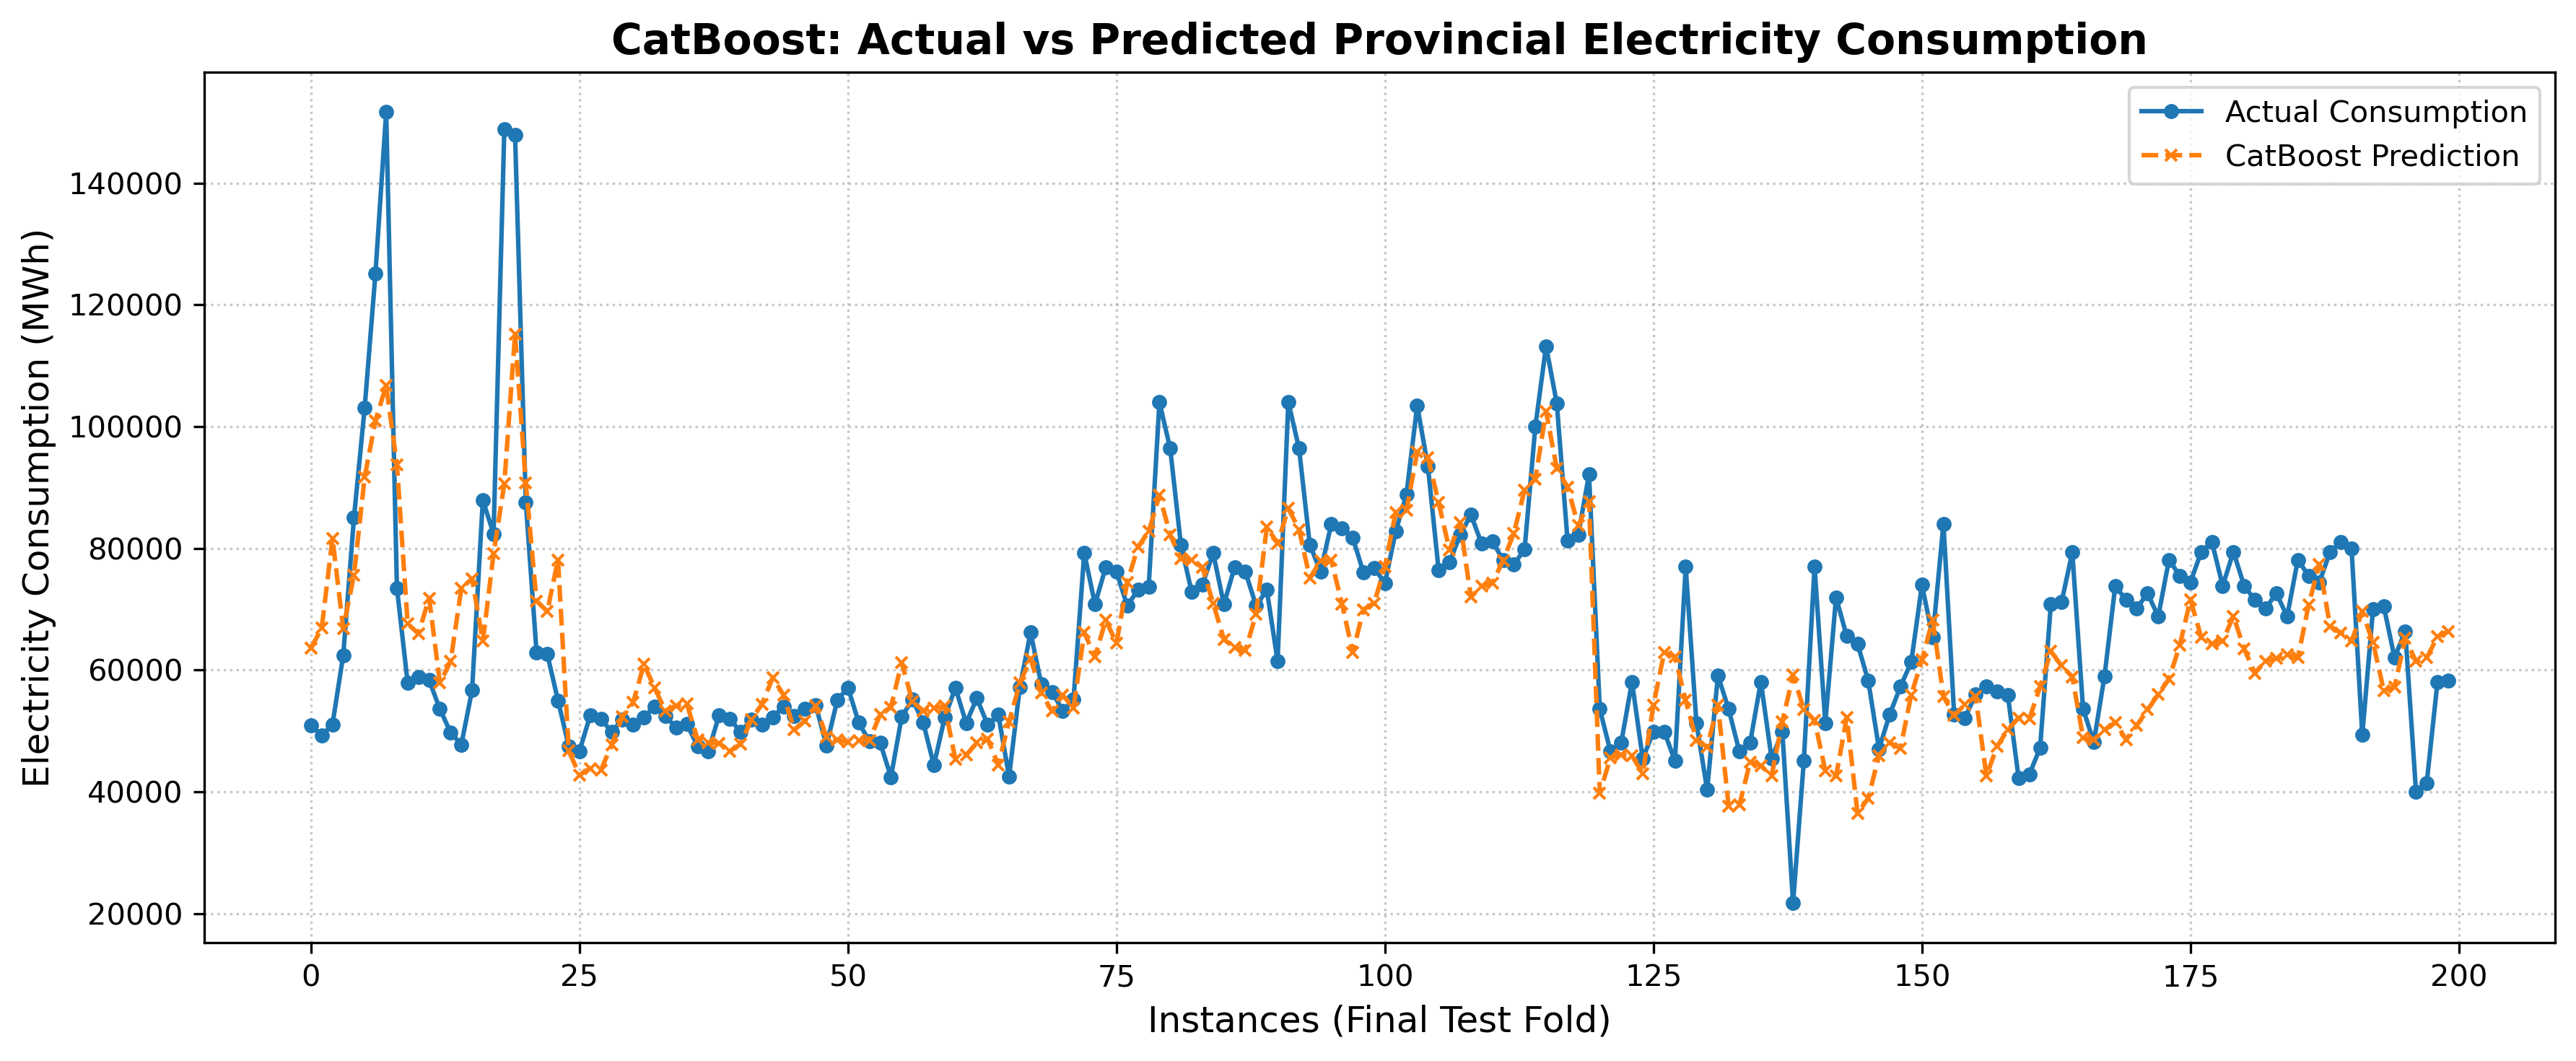

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ---------------------------------------------------------
# 1) DIEBOLD-MARIANO TEST FUNCTION
# ---------------------------------------------------------
def diebold_mariano(y_true, y_pred1, y_pred2):
    e1 = y_true - y_pred1
    e2 = y_true - y_pred2
    d = e1**2 - e2**2
    mean_d = np.mean(d)
    var_d = np.var(d, ddof=1)
    dm_stat = mean_d / np.sqrt(var_d / len(d))
    p_value = 2 * (1 - stats.norm.cdf(np.abs(dm_stat)))
    return dm_stat, p_value

def main():
    # ---------------------------------------------------------
    # 2) DATA LOADING
    # ---------------------------------------------------------
    OUTPUT_PATH = os.path.join("..", "..", "processed_data", "final", "ML_En.xlsx")
    
    df = pd.read_excel(OUTPUT_PATH)
    df["Plate"] = df["Plate"].astype(str).str.lower()
    df = df.sort_values(["Plate", "Year", "Month"]).reset_index(drop=True)

    # ---------------------------------------------------------
    # 3) LAG FEATURES
    # ---------------------------------------------------------
    lag = 12
    for l in range(1, lag + 1):
        df[f"lag_{l}"] = df.groupby("Plate")["Consumption"].shift(l)

    df = df.dropna().reset_index(drop=True)

    # ---------------------------------------------------------
    # 4) FEATURE ENGINEERING
    # ---------------------------------------------------------
    features = [
        "Lighting", "Public", "Residential", "Industry", "Agriculture",
        "Population", "Month", "Season", "Region", "Latitude", "Longitude",
        "Daylight Duration", "Altitude"
    ] + [f"lag_{i}" for i in range(1, lag + 1)]

    X = df[features].copy()
    y = df["Consumption"].values

    cat_cols = ["Region", "Season"]
    for col in cat_cols:
        X[col] = X[col].astype(str)

    cat_features_indices = [X.columns.get_loc(c) for c in cat_cols]

    # ---------------------------------------------------------
    # 5) TIME SERIES CROSS-VALIDATION
    # ---------------------------------------------------------
    tscv = TimeSeriesSplit(n_splits=5)
    fold_metrics = []

    print("Starting CatBoost Time-Series Cross-Validation...")

    final_y_true = None
    final_y_pred = None

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X), 1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        train_pool = Pool(X_train, y_train, cat_features=cat_features_indices)
        test_pool  = Pool(X_test, y_test, cat_features=cat_features_indices)

        model = CatBoostRegressor(
            iterations=800,
            learning_rate=0.05,
            depth=6,
            eval_metric='RMSE',
            random_seed=42,
            verbose=0
        )

        model.fit(train_pool, eval_set=test_pool, early_stopping_rounds=50, verbose=0)
        y_pred = model.predict(X_test)

        # --- DÜZELTİLMİŞ METRİK HESAPLAMALARI ---
        y_range = y_test.max() - y_test.min()
        y_range_safe = y_range if y_range != 0 else 1

        # Ham Hatalar
        mse_val = mean_squared_error(y_test, y_pred)
        mae_val = mean_absolute_error(y_test, y_pred)

        # Normalizasyon (NMSE hatası paydanın karesi alınarak düzeltildi)
        nmse = mse_val / (y_range_safe ** 2)
        nmae = mae_val / y_range_safe
        r2 = r2_score(y_test, y_pred)
        mape = np.mean(np.abs((y_test - y_pred) / (np.abs(y_test) + 1e-10))) * 100

        fold_metrics.append([r2, nmse, nmae, mape])
        print(f"Fold {fold} completed: R²={r2:.4f}, NMSE={nmse:.4f}, NMAE={nmae:.4f}")

        if fold == tscv.n_splits:
            final_y_true = y_test 
            final_y_pred = y_pred

    # ---------------------------------------------------------
    # 6) AVERAGE CV RESULTS (Mean ± STD)
    # ---------------------------------------------------------
    fold_metrics = np.array(fold_metrics)
    print("\n" + "="*45)
    print("========= CATBOOST TIME-SERIES CV RESULTS =========")
    print("="*45)
    print(f"NMAE : {fold_metrics[:,2].mean():.4f} ± {fold_metrics[:,2].std():.4f}")
    print(f"NMSE : {fold_metrics[:,1].mean():.4f} ± {fold_metrics[:,1].std():.4f}")
    print(f"R²   : {fold_metrics[:,0].mean():.4f} ± {fold_metrics[:,0].std():.4f}")
    print(f"MAPE : {fold_metrics[:,3].mean():.2f}% ± {fold_metrics[:,3].std():.2f}%")
    print("="*45)

    # ---------------------------------------------------------
    # 7) DIEBOLD-MARIANO TEST (vs Naive)
    # ---------------------------------------------------------
    y_naive = pd.Series(final_y_true).shift(12).bfill().values
    dm_stat, p_value = diebold_mariano(final_y_true, final_y_pred, y_naive)
    print("\n" + "="*45)
    print("========== DIEBOLD-MARIANO TEST RESULT ==========")
    print("="*45)
    print(f"Comparison : CatBoost Prediction vs. Naive Baseline (Lag 12)")
    print(f"DM Stat    : {dm_stat:.4f}")
    print(f"p-value    : {p_value:.4f}")
    print("="*45)

    # ---------------------------------------------------------
    # 8) PLOTTING (GRAFİK ORİJİNAL MWh DEĞERLERİYLE)
    # ---------------------------------------------------------
    plt.figure(figsize=(12, 5), dpi=300) 
    plot_limit = min(200, len(final_y_true))
    
    plt.plot(final_y_true[:plot_limit], label='Actual Consumption', color='#1f77b4', marker='o', markersize=4, linewidth=1.5)
    plt.plot(final_y_pred[:plot_limit], label='CatBoost Prediction', color='#ff7f0e', marker='x', markersize=4, linestyle='--', linewidth=1.5)
    
    plt.title("CatBoost: Actual vs Predicted Provincial Electricity Consumption", fontsize=14, fontweight='bold')
    plt.xlabel("Instances (Final Test Fold)", fontsize=12)
    plt.ylabel("Electricity Consumption (MWh)", fontsize=12)
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.tight_layout()
    plt.savefig("catboost_n_metrics_plot.png")
    plt.show()

if __name__ == "__main__":
    main()